# Day 08. Exercise 01
# Binary classifier. SVM. Decision tree

## 0. Imports

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree

## 1. Preprocessing and logreg visualization

Read the file `am_pm.csv` to a dataframe from the previous exercise.

1. Draw a plot where the x-axis is `am`, the y-axis is `pm`, dots are the days, color depends on the target.
2. Add the decision boundary of logistic regression to the plot.
3. Draw the same plot (with the boundary), but the color should depend this time on the predictions.

Now it should be clear for you how the logistic regression works.

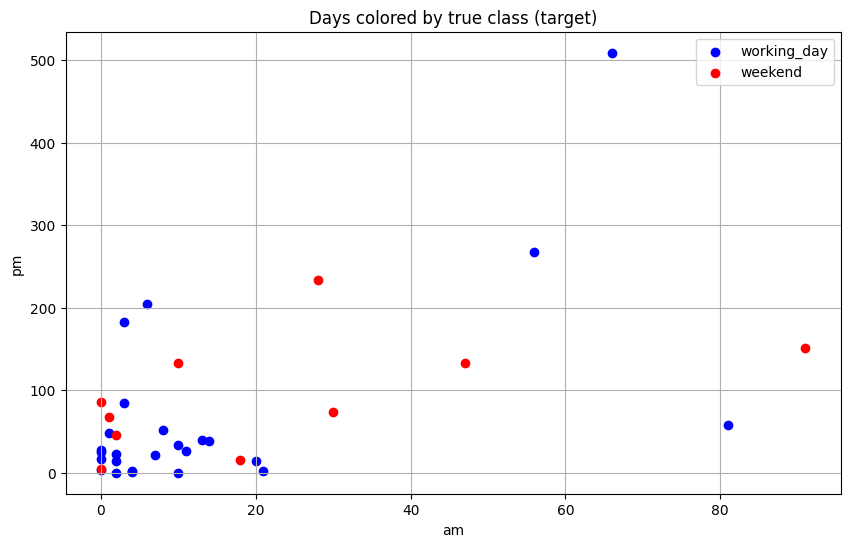

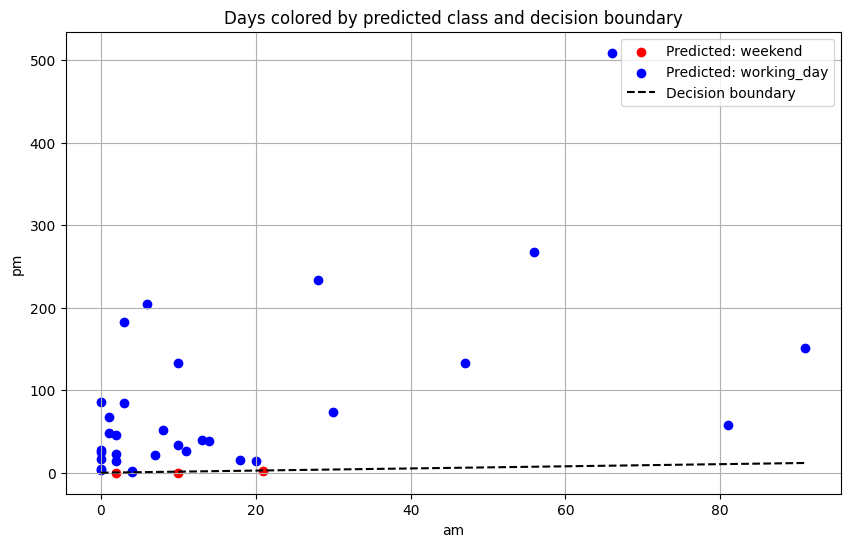

In [25]:
df = pd.read_csv('../data/am_pm.csv')

colors = {'working_day': 'blue', 'weekend': 'red'}

plt.figure(figsize=(10, 6))
for t in df['target'].unique():
    subset = df[df['target'] == t]
    plt.scatter(subset['am'], subset['pm'], label=t, color=colors[t])
plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.grid(True)
plt.title('Days colored by true class (target)')
plt.show()

X = df[['am', 'pm']]
y = (df['target'] == 'working_day').astype(int)

model = LogisticRegression(fit_intercept=False, random_state=21)
model.fit(X, y)

w0, w1 = model.coef_[0]

x_vals = np.linspace(df['am'].min(), df['am'].max(), 100)
y_vals = - (w0 / w1) * x_vals

plt.figure(figsize=(10, 6))
for t in df['predict'].unique():
    subset = df[df['predict'] == t]
    plt.scatter(subset['am'], subset['pm'], label=f'Predicted: {t}', color=colors[t])
plt.plot(x_vals, y_vals, 'k--', label='Decision boundary')
plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.grid(True)
plt.title('Days colored by predicted class and decision boundary')
plt.show()

## 2. Standardizing and logreg

Linear models can be sensitive to the scale of your variables. You make it easier for them to find the optimal solution when you scale your features.

1. Apply `StandardScaler` to `X` and train logistic regression again with the same parameters.
2. Calculate `accuracy` for the new model. Did it get better than a naive classifier with the most popular class?
3. Draw the plots that were described above but for the new model.

Accuracy новой модели: 0.7428571428571429
Accuracy наивного классификатора: 0.7142857142857143


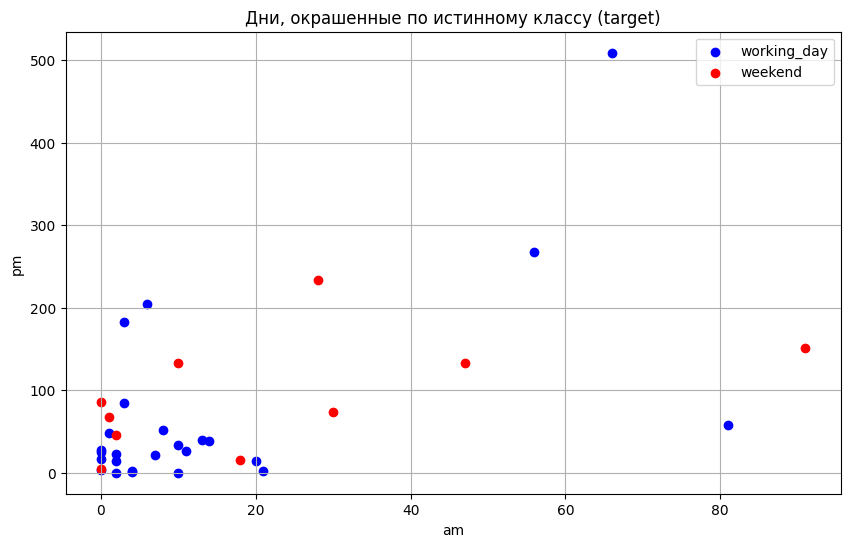

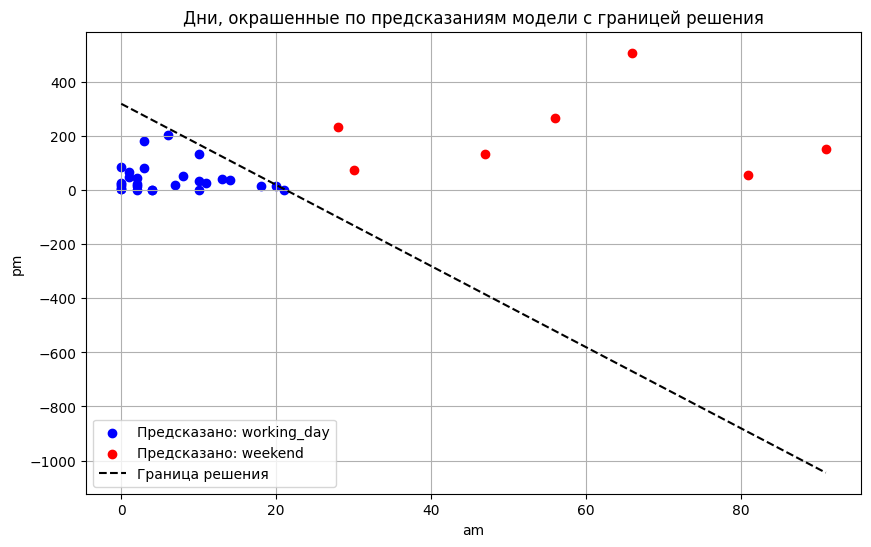

In [26]:
X = df[['am', 'pm']].values
y = (df['target'] == 'working_day').astype(int).values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression(fit_intercept=False, random_state=21)
model.fit(X_scaled, y)

y_pred = model.predict(X_scaled)
df['predict_scaled'] = ['working_day' if p == 1 else 'weekend' for p in y_pred]

accuracy_new = accuracy_score(y, y_pred)

most_popular_class = 1 if np.sum(y) >= len(y)/2 else 0
y_naive = np.full_like(y, most_popular_class)
accuracy_naive = accuracy_score(y, y_naive)

print(f'Accuracy новой модели: {accuracy_new:}')
print(f'Accuracy наивного классификатора: {accuracy_naive:}')

colors = {'working_day': 'blue', 'weekend': 'red'}

plt.figure(figsize=(10, 6))
for t in df['target'].unique():
    subset = df[df['target'] == t]
    plt.scatter(subset['am'], subset['pm'], label=t, color=colors[t])
plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.grid(True)
plt.title('Дни, окрашенные по истинному классу (target)')
plt.show()

w0, w1 = model.coef_[0]

x_vals = np.linspace(df['am'].min(), df['am'].max(), 100)
x_vals_scaled = (x_vals - scaler.mean_[0]) / scaler.scale_[0]
y_vals_scaled = - (w0 / w1) * x_vals_scaled
y_vals = y_vals_scaled * scaler.scale_[1] + scaler.mean_[1]

plt.figure(figsize=(10, 6))
for t in df['predict_scaled'].unique():
    subset = df[df['predict_scaled'] == t]
    plt.scatter(subset['am'], subset['pm'], label=f'Предсказано: {t}', color=colors[t])

plt.plot(x_vals, y_vals, 'k--', label='Граница решения')

plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.grid(True)
plt.title('Дни, окрашенные по предсказаниям модели с границей решения')

plt.show()

## 3. SVM

1. Apply `SVC` model to the scaled dataframe using parameters `probability=True`, `random_state=21`.
2. Calculate `accuracy`.
3. Try different kernels, find the best in terms of accuracy.
4. Draw both plots again with the decisions boundary to see how this algorithm works.

Kernel=linear: Accuracy = 0.7142857142857143
Kernel=poly: Accuracy = 0.7428571428571429
Kernel=rbf: Accuracy = 0.7428571428571429
Kernel=sigmoid: Accuracy = 0.6857142857142857

Лучшее ядро: poly с accuracy = 0.7428571428571429


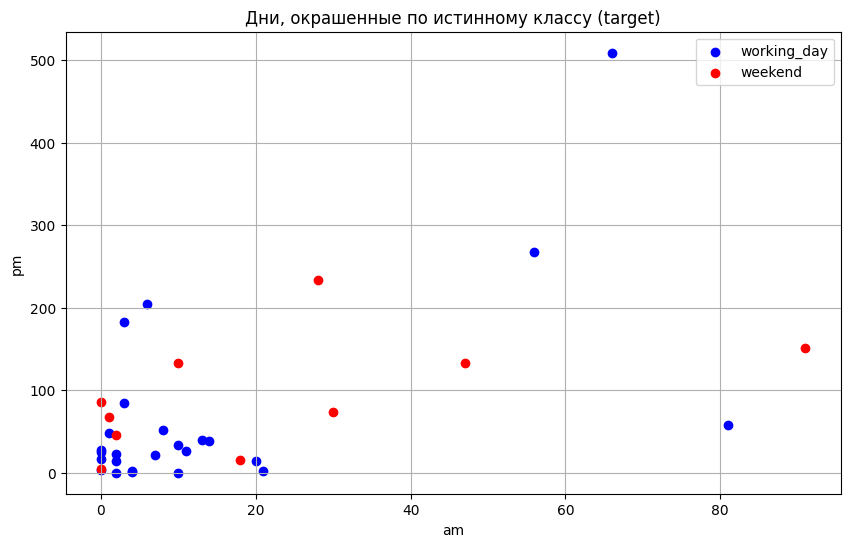

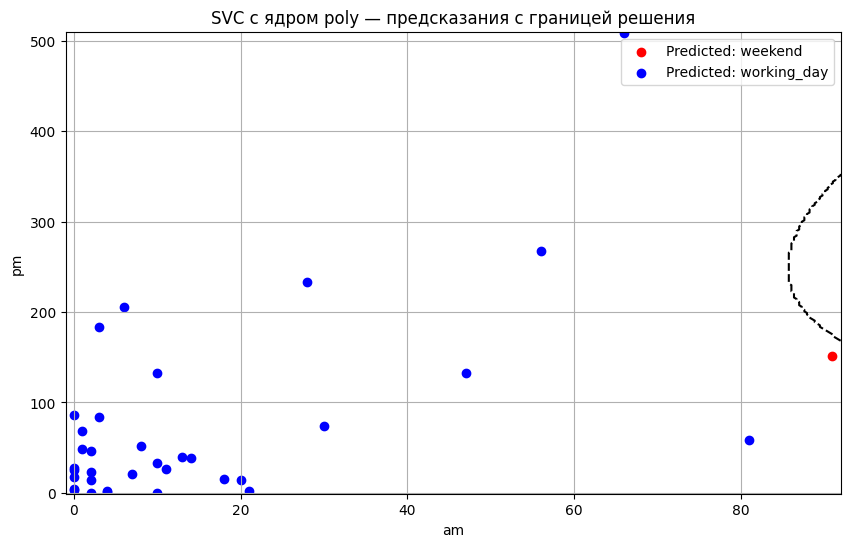

In [27]:

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

def train_and_evaluate_svc(kernel_name):
    svc = SVC(kernel=kernel_name, probability=True, random_state=21)
    svc.fit(X_scaled, y)
    y_pred = svc.predict(X_scaled)
    acc = accuracy_score(y, y_pred)
    print(f'Kernel={kernel_name}: Accuracy = {acc}')
    return svc, y_pred, acc

kernels = ['linear', 'poly', 'rbf', 'sigmoid']
best_acc = 0
best_kernel = None
best_model = None
best_pred = None

for k in kernels:
    model, pred, acc = train_and_evaluate_svc(k)
    if acc > best_acc:
        best_acc = acc
        best_kernel = k
        best_model = model
        best_pred = pred

print(f'\nЛучшее ядро: {best_kernel} с accuracy = {best_acc}')

df['predict_svc'] = ['working_day' if p == 1 else 'weekend' for p in best_pred]

def plot_with_decision_boundary(model, y_pred_labels, title, colors):
    plt.figure(figsize=(10,6))
    for cls in np.unique(y_pred_labels):
        subset = df[np.array(y_pred_labels) == cls]
        plt.scatter(subset['am'], subset['pm'], label=f'Predicted: {cls}', color=colors[cls])
    x_min, x_max = df['am'].min() - 1, df['am'].max() + 1
    y_min, y_max = df['pm'].min() - 1, df['pm'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    grid_scaled = scaler.transform(grid)
    probs = model.predict_proba(grid_scaled)[:, 1]
    probs = probs.reshape(xx.shape)
    plt.contour(xx, yy, probs, levels=[0.5], colors='k', linestyles='--')
    plt.xlabel('am')
    plt.ylabel('pm')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

colors = {'working_day': 'blue', 'weekend': 'red'}

plt.figure(figsize=(10, 6))
for t in df['target'].unique():
    subset = df[df['target'] == t]
    plt.scatter(subset['am'], subset['pm'], label=t, color=colors[t])
plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.grid(True)
plt.title('Дни, окрашенные по истинному классу (target)')
plt.show()

plot_with_decision_boundary(
    best_model,
    df['predict_svc'],
    f'SVC с ядром {best_kernel} — предсказания с границей решения',
    colors
)

## 4. Decision tree

1. Apply `DecisionTreeClassifier` to the scaled dataframe using parameters `max_depth=4`, `random_state=42`.
2. Calculate accuracy.
3. Try different values of `max_depth`.
4. Draw both plots again with the decisions boundary to see how this algorithm works.
5. Using method `.plot_tree()` visualize the decision tree itself. It is another way of thinking about how the algorithm works.
6. How many leaves in the visualized tree label days as working days? Put your answer in the markdown cell in the end of the section.

Accuracy (max_depth=4): 0.9428571428571428
max_depth=1: accuracy=0.7714285714285715
max_depth=2: accuracy=0.8571428571428571
max_depth=3: accuracy=0.8857142857142857
max_depth=4: accuracy=0.9428571428571428
max_depth=5: accuracy=0.9714285714285714
max_depth=6: accuracy=1.0
max_depth=7: accuracy=1.0
max_depth=8: accuracy=1.0
max_depth=9: accuracy=1.0


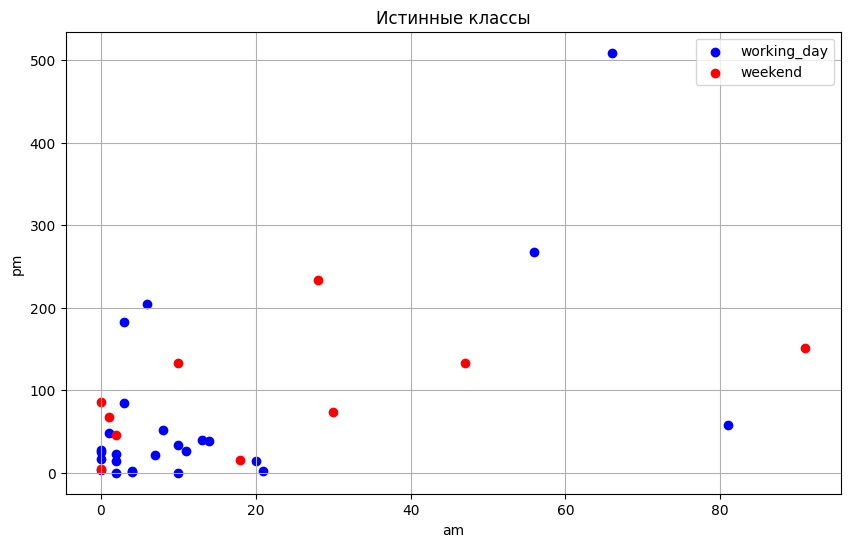

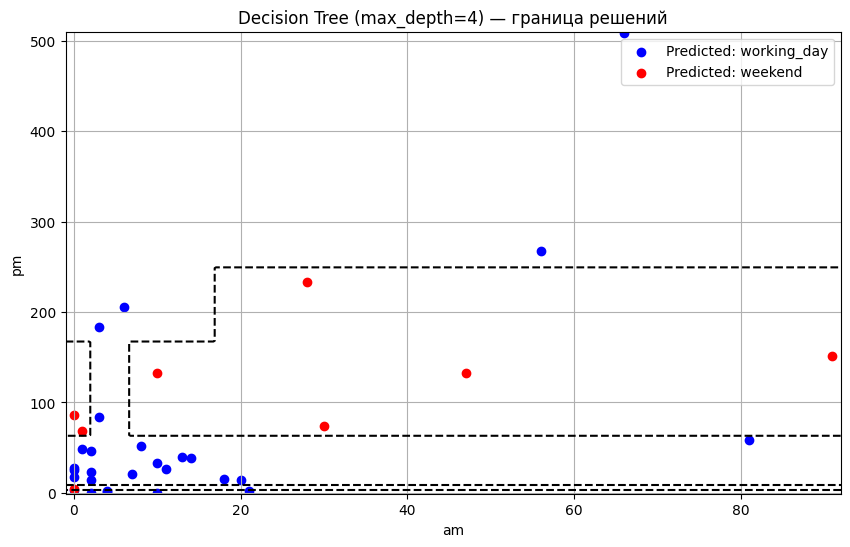

In [28]:
X = df[['am', 'pm']].values
y = (df['target'] == 'working_day').astype(int).values

tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)
y_pred = tree.predict(X)
acc = accuracy_score(y, y_pred)
print(f"Accuracy (max_depth=4): {acc:}")

accuracies = []
for depth in range(1, 10):
    t = DecisionTreeClassifier(max_depth=depth, random_state=42)
    t.fit(X, y)
    y_pred = t.predict(X)
    acc = accuracy_score(y, y_pred)
    accuracies.append(acc)
    print(f"max_depth={depth}: accuracy={acc:}")

best_depth = np.argmax(accuracies) + 1

df['predict_tree'] = np.where(tree.predict(X) == 1, 'working_day', 'weekend')
colors = {'working_day': 'blue', 'weekend': 'red'}

def plot_tree_decision_boundary_line(model, df, title, colors):
    plt.figure(figsize=(10, 6))
    for t in df['predict_tree'].unique():
        subset = df[df['predict_tree'] == t]
        plt.scatter(subset['am'], subset['pm'], label=f'Predicted: {t}', color=colors[t])
    x_min, x_max = df['am'].min() - 1, df['am'].max() + 1
    y_min, y_max = df['pm'].min() - 1, df['pm'].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)
    plt.contour(xx, yy, Z, levels=[0.5], colors='k', linestyles='--')
    plt.xlabel('am')
    plt.ylabel('pm')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plt.figure(figsize=(10, 6))
for t in df['target'].unique():
    subset = df[df['target'] == t]
    plt.scatter(subset['am'], subset['pm'], label=t, color=colors[t])
plt.xlabel('am')
plt.ylabel('pm')
plt.legend()
plt.title('Истинные классы')
plt.grid(True)
plt.show()

plot_tree_decision_boundary_line(tree, df,
    'Decision Tree (max_depth=4) — граница решений', colors)

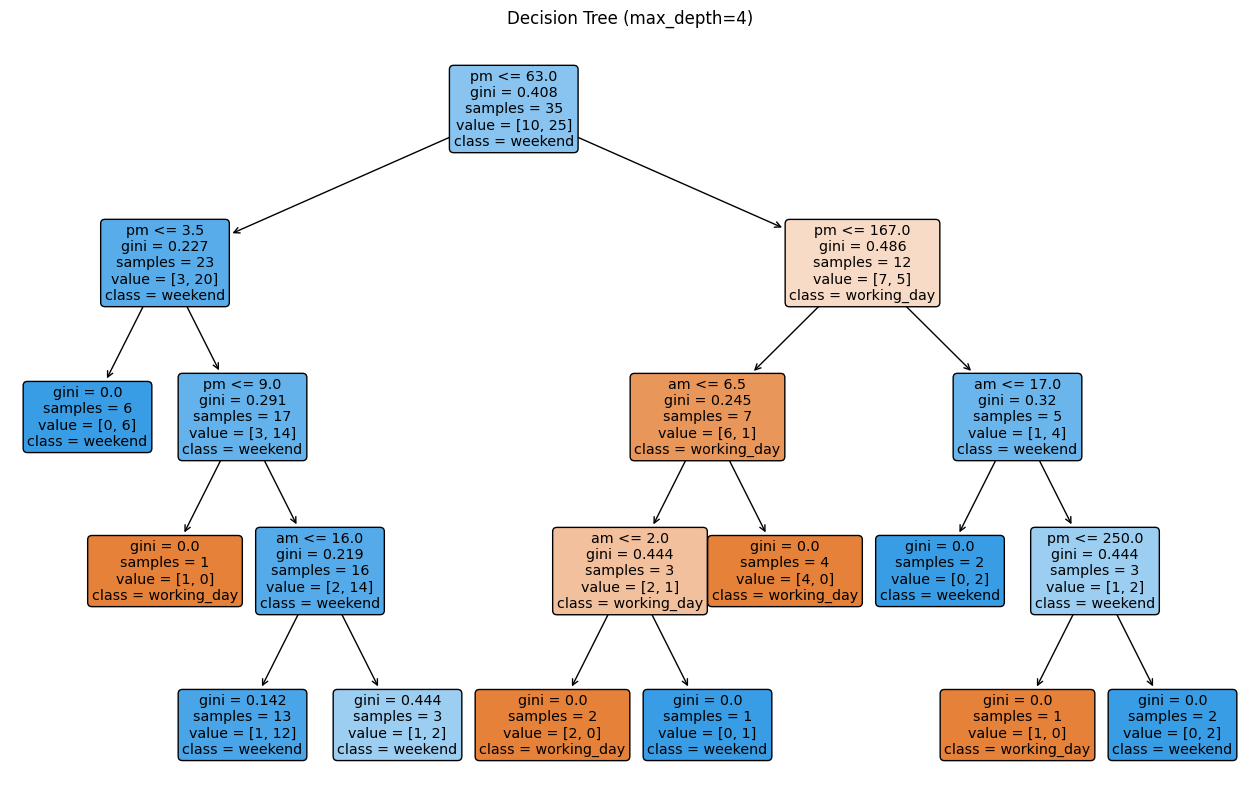

In [29]:
plt.figure(figsize=(16, 10))
plot_tree(tree, feature_names=['am', 'pm'], class_names=['working_day', 'weekend'],
          filled=True, rounded=True)
plt.title('Decision Tree (max_depth=4)')
plt.show()

кол-во листьев: 4